In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#%pip install kagglehub[pandas-datasets]

In [3]:
#Carico il dataset della produzione di energia rinnovabile
#In questo dataset sono presenti direttamente i dati della produzione (Pv) di energia rinnovabile espressi in MWh
#Quindi dovremmo sia scalara l'energia per la microgrid, sia per la dimensione delle misurazioni, 
# in quanto questo dataset interessa tutta la produzione energetica della Francia dal 2020 al 2025

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = ""

# Load the latest version
file_path = "Energy Production Dataset.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "ahmeduzaki/wind-and-solar-energy-production-dataset",
    file_path,
    # Provide any additional arguments like 
    # sql_query or pandas_kwargs. See the 
    # documenation for more information:
    # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

C:\Users\vinsc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\vinsc\AppData\Local\Temp\ipykernel_23248\264206530.py:15: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [4]:
print(df)

             Date  Start_Hour  End_Hour Source  Day_of_Year   Day_Name  \
0      11/30/2025          21        22   Wind          334     Sunday   
1      11/30/2025          18        19   Wind          334     Sunday   
2      11/30/2025          16        17   Wind          334     Sunday   
3      11/30/2025          23         0   Wind          334     Sunday   
4      11/30/2025           6         7   Wind          334     Sunday   
...           ...         ...       ...    ...          ...        ...   
51859    1/1/2020           4         5   Wind            1  Wednesday   
51860    1/1/2020          18        19   Wind            1  Wednesday   
51861    1/1/2020           7         8   Wind            1  Wednesday   
51862    1/1/2020          14        15  Solar            1  Wednesday   
51863    1/1/2020          13        14  Solar            1  Wednesday   

      Month_Name  Season  Production  
0       November    Fall        5281  
1       November    Fall        3

In [5]:
#In questa cella scalo i dati della produzione per la microgrid, considerando la produzione di energia rinnovabile (solare e eolica)
# ottenuta nel 2014 in Francia e in Inghilterra.
#Dati di produzione di energia rinnovabile nel Regno Unito nel 2024
production_uk_2024 = 97.7  # TWh
#Dati di produzione di energia rinnovabile in Francia nel 2024
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
production_by_year = df.groupby('Year')['Production'].sum().reset_index()

#Lo convertiamo in TWh, dato che i dati sono in MWh
production_by_year['Production'] = production_by_year['Production'] / 1e6
print(production_by_year)
#Considero solo la produzione del 2024
production_france_2024 = production_by_year[production_by_year['Year'] == 2024]['Production'].values[0]
print(f"Production in France in 2024: {production_france_2024} TWh")

# Il Regno Unito produce molta più energia rinnovabile (solare e eolica)rispetto alla Francia perché non viene considerato l'apporto
# dell'energia nucleare, che invece è molto presente in Francia.

#Calcolo il rapporto tra la produzione di energia rinnovabile del Regno Unito e della Francia
scaling_factor = production_uk_2024 / production_france_2024
print(f"Scaling factor: {scaling_factor}")

#Moltiplico la colonna della Produzione per il fattore di conversione per ottenere i dati scalati per il Regno Unito
df['Scaled_Production'] = df['Production'] * scaling_factor

#Calcolo di nuovo la produzione totale scalata per il 2024 in TWh
scaled_production_by_year = df.groupby('Year')['Scaled_Production'].sum().reset_index()
scaled_production_by_year['Scaled_Production'] = scaled_production_by_year['Scaled_Production'] / 1e6
print(scaled_production_by_year)

   Year  Production
0  2020   46.903255
1  2021   45.717690
2  2022   49.748463
3  2023   63.459869
4  2024   59.126127
5  2025   57.382983
Production in France in 2024: 59.126127 TWh
Scaling factor: 1.6523997927346064
   Year  Scaled_Production
0  2020          77.502929
1  2021          75.543901
2  2022          82.204350
3  2023         104.861074
4  2024          97.700000
5  2025          94.819629


In [6]:
#Trasformo la colonna Scaled_Production in kWh dai dati in MWh, moltiplicando per 10^6
df['Scaled_Production_kWh'] = df['Scaled_Production'] * 1e6
print(df[['Date','Scaled_Production', 'Scaled_Production_kWh']])

            Date  Scaled_Production  Scaled_Production_kWh
0     2025-11-30        8726.323305           8.726323e+09
1     2025-11-30        6318.776807           6.318777e+09
2     2025-11-30        6318.776807           6.318777e+09
3     2025-11-30       10112.686732           1.011269e+10
4     2025-11-30        7249.077891           7.249078e+09
...          ...                ...                    ...
51859 2020-01-01        4474.698639           4.474699e+09
51860 2020-01-01        1779.634577           1.779635e+09
51861 2020-01-01        3432.034370           3.432034e+09
51862 2020-01-01        2946.228830           2.946229e+09
51863 2020-01-01        3600.579148           3.600579e+09

[51864 rows x 3 columns]


In [7]:
#Faccio la media per capire quanta energia viene prodotta al giorno
production_by_day = df.groupby('Date')['Scaled_Production_kWh'].sum().reset_index()

production_by_day['Production_kW_day'] = production_by_day['Scaled_Production_kWh'] / (1e10)

print(production_by_day)

print(production_by_day["Production_kW_day"].mean())

           Date  Scaled_Production_kWh  Production_kW_day
0    2020-01-01           7.802962e+10           7.802962
1    2020-01-02           1.476816e+11          14.768158
2    2020-01-03           2.965843e+11          29.658428
3    2020-01-04           1.398591e+11          13.985912
4    2020-01-05           8.138565e+10           8.138565
...         ...                    ...                ...
2156 2025-11-26           2.126077e+11          21.260767
2157 2025-11-27           3.497271e+11          34.972711
2158 2025-11-28           3.171434e+11          31.714344
2159 2025-11-29           3.868995e+11          38.689950
2160 2025-11-30           2.058510e+11          20.585101

[2161 rows x 3 columns]
24.647472645497796


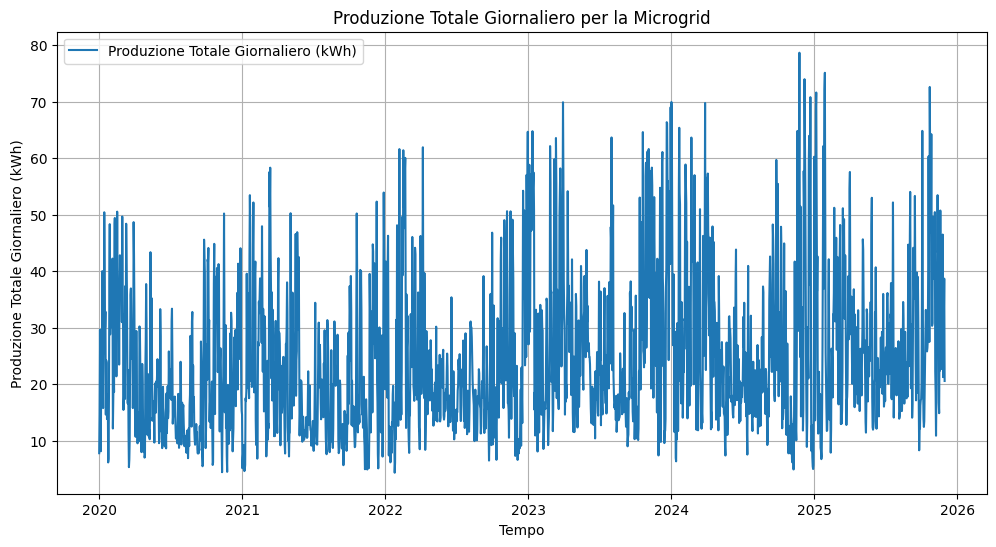

In [8]:
# Grafico la Production_kW_day
plt.figure(figsize=(12, 6))
plt.plot(production_by_day['Date'], production_by_day['Production_kW_day'], label="Produzione Totale Giornaliero (kWh)")
plt.xlabel("Tempo")
plt.ylabel("Produzione Totale Giornaliero (kWh)")
plt.title("Produzione Totale Giornaliero per la Microgrid")
plt.legend()
plt.grid()
plt.show()


In [9]:
#Scalo correttamente la colonna Production e tolglo le colonne che non servono
df['Pv'] = df['Scaled_Production_kWh'] / 1e10

# Unisco la colonna Date e Start_Hour per una formattazione del tipo: YYYY-MM-DD HH:MM:SS
df['DateTime'] = pd.to_datetime(
    df['Date'].astype(str) + ' ' +
    df['Start_Hour'].astype(str).str.zfill(2) + ':00:00'
)

Tabella_Pv = df[['DateTime','Day_of_Year','Day_Name', 'Month_Name',  'Season',  'Year',  'Pv']]



#Controllo se ci sono valori di Time ripetuti o mancanti
print(Tabella_Pv.index.duplicated().sum())  # Conta i duplicati
print(Tabella_Pv.index.isnull().sum())  # Conta i valori mancanti

print(Tabella_Pv)

0
0
                 DateTime  Day_of_Year   Day_Name Month_Name  Season  Year  \
0     2025-11-30 21:00:00          334     Sunday   November    Fall  2025   
1     2025-11-30 18:00:00          334     Sunday   November    Fall  2025   
2     2025-11-30 16:00:00          334     Sunday   November    Fall  2025   
3     2025-11-30 23:00:00          334     Sunday   November    Fall  2025   
4     2025-11-30 06:00:00          334     Sunday   November    Fall  2025   
...                   ...          ...        ...        ...     ...   ...   
51859 2020-01-01 04:00:00            1  Wednesday    January  Winter  2020   
51860 2020-01-01 18:00:00            1  Wednesday    January  Winter  2020   
51861 2020-01-01 07:00:00            1  Wednesday    January  Winter  2020   
51862 2020-01-01 14:00:00            1  Wednesday    January  Winter  2020   
51863 2020-01-01 13:00:00            1  Wednesday    January  Winter  2020   

             Pv  
0      0.872632  
1      0.631878  
2    

In [10]:
print(Tabella_Pv)
#Salvo Taeblla_Pv in un file csv con il nome "Tabella_Pv.csv" in C:\Users\vinsc\Documents\Progetti
Tabella_Pv.to_csv(r"C:\Users\vinsc\Documents\Progetti\Tabella_Pv.csv", index=True)

                 DateTime  Day_of_Year   Day_Name Month_Name  Season  Year  \
0     2025-11-30 21:00:00          334     Sunday   November    Fall  2025   
1     2025-11-30 18:00:00          334     Sunday   November    Fall  2025   
2     2025-11-30 16:00:00          334     Sunday   November    Fall  2025   
3     2025-11-30 23:00:00          334     Sunday   November    Fall  2025   
4     2025-11-30 06:00:00          334     Sunday   November    Fall  2025   
...                   ...          ...        ...        ...     ...   ...   
51859 2020-01-01 04:00:00            1  Wednesday    January  Winter  2020   
51860 2020-01-01 18:00:00            1  Wednesday    January  Winter  2020   
51861 2020-01-01 07:00:00            1  Wednesday    January  Winter  2020   
51862 2020-01-01 14:00:00            1  Wednesday    January  Winter  2020   
51863 2020-01-01 13:00:00            1  Wednesday    January  Winter  2020   

             Pv  
0      0.872632  
1      0.631878  
2      0.